# Saturating response to antigen

In [1]:
import numpy as np
import pyrepseq as prs

import matplotlib.pyplot as plt

import repertoire_simulator.lib as lib

plt.style.use("../../project_style.mplstyle")
%config InlineBackend.figure_format = 'retina'

DATA_PATH = "../../data/"

/Users/james/Documents/Projects/repertoire_sims_2026/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Changing the saturation threshold

In [2]:
theta_over_D = 1e4
gamma = 0.2 
alpha = 1.2
T_star = theta_over_D / (alpha - 1) 

In [3]:
epsilons = np.logspace(np.log10(0.1 / T_star), -1, 10)
results_for_epsilon = {}
cs_final_for_epsilon = {}
cmaxes_for_epsilon = {}
for epsilon in epsilons:
    records = np.load(DATA_PATH + f"how_to_maintain_diversity/saturating_response/log_epsilon_{np.log10(epsilon):.1f}.npz", allow_pickle=True)
    t = records['t']
    c_t = records['c']
    Seff = np.zeros(len(t))
    T = np.zeros(len(t))
    S = np.zeros(len(t))
    cmax = np.zeros(len(t))
    
    cs_final_for_epsilon[epsilon] = c_t[-1]
    for i, time in enumerate(t):
        Seff[i] = lib.get_average_simpsons_diversity(c_t[i])
        T[i] = np.mean(c_t[i].sum(axis=0))
        S[i] = int(np.sum(np.all(c_t[i] > 0.1, axis=1)))
        cmax[i] = np.max(c_t[i])
        
    results_for_epsilon[epsilon] = {'t':t, 'Seff':Seff, 'T':T, 'S':S, 'cmax':cmax}

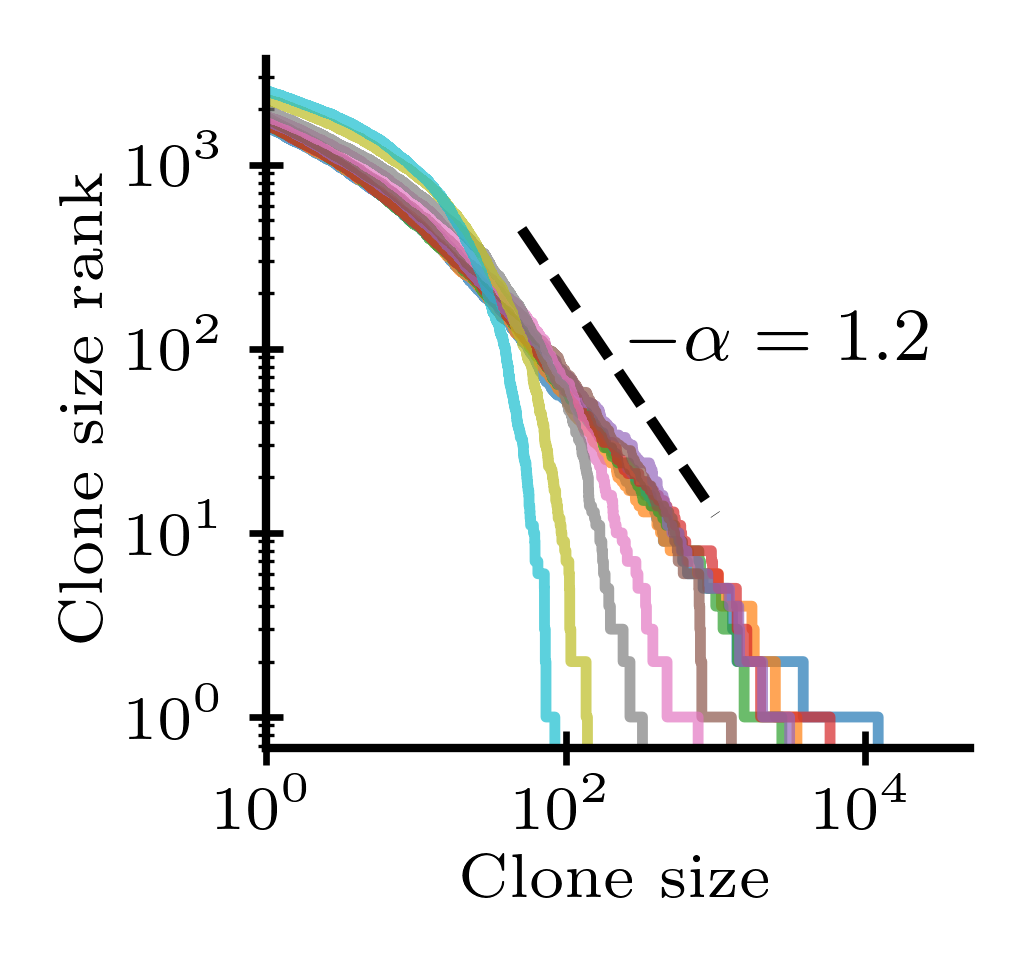

In [4]:
fig, ax = plt.subplots(figsize=(1.6, 1.5), layout='constrained')
lib.plot_referencescaling(ax=ax, x=[51, 1e3], factor=5e4, exponent=-1.2, linestyle='--')
for epsilon in epsilons:
    c = cs_final_for_epsilon[epsilon]
    prs.plotting.rankfrequency(c[c >= 1], ax=ax, normalize_x=False, alpha=0.7)
ax.set_xlim([1e0, T_star]);

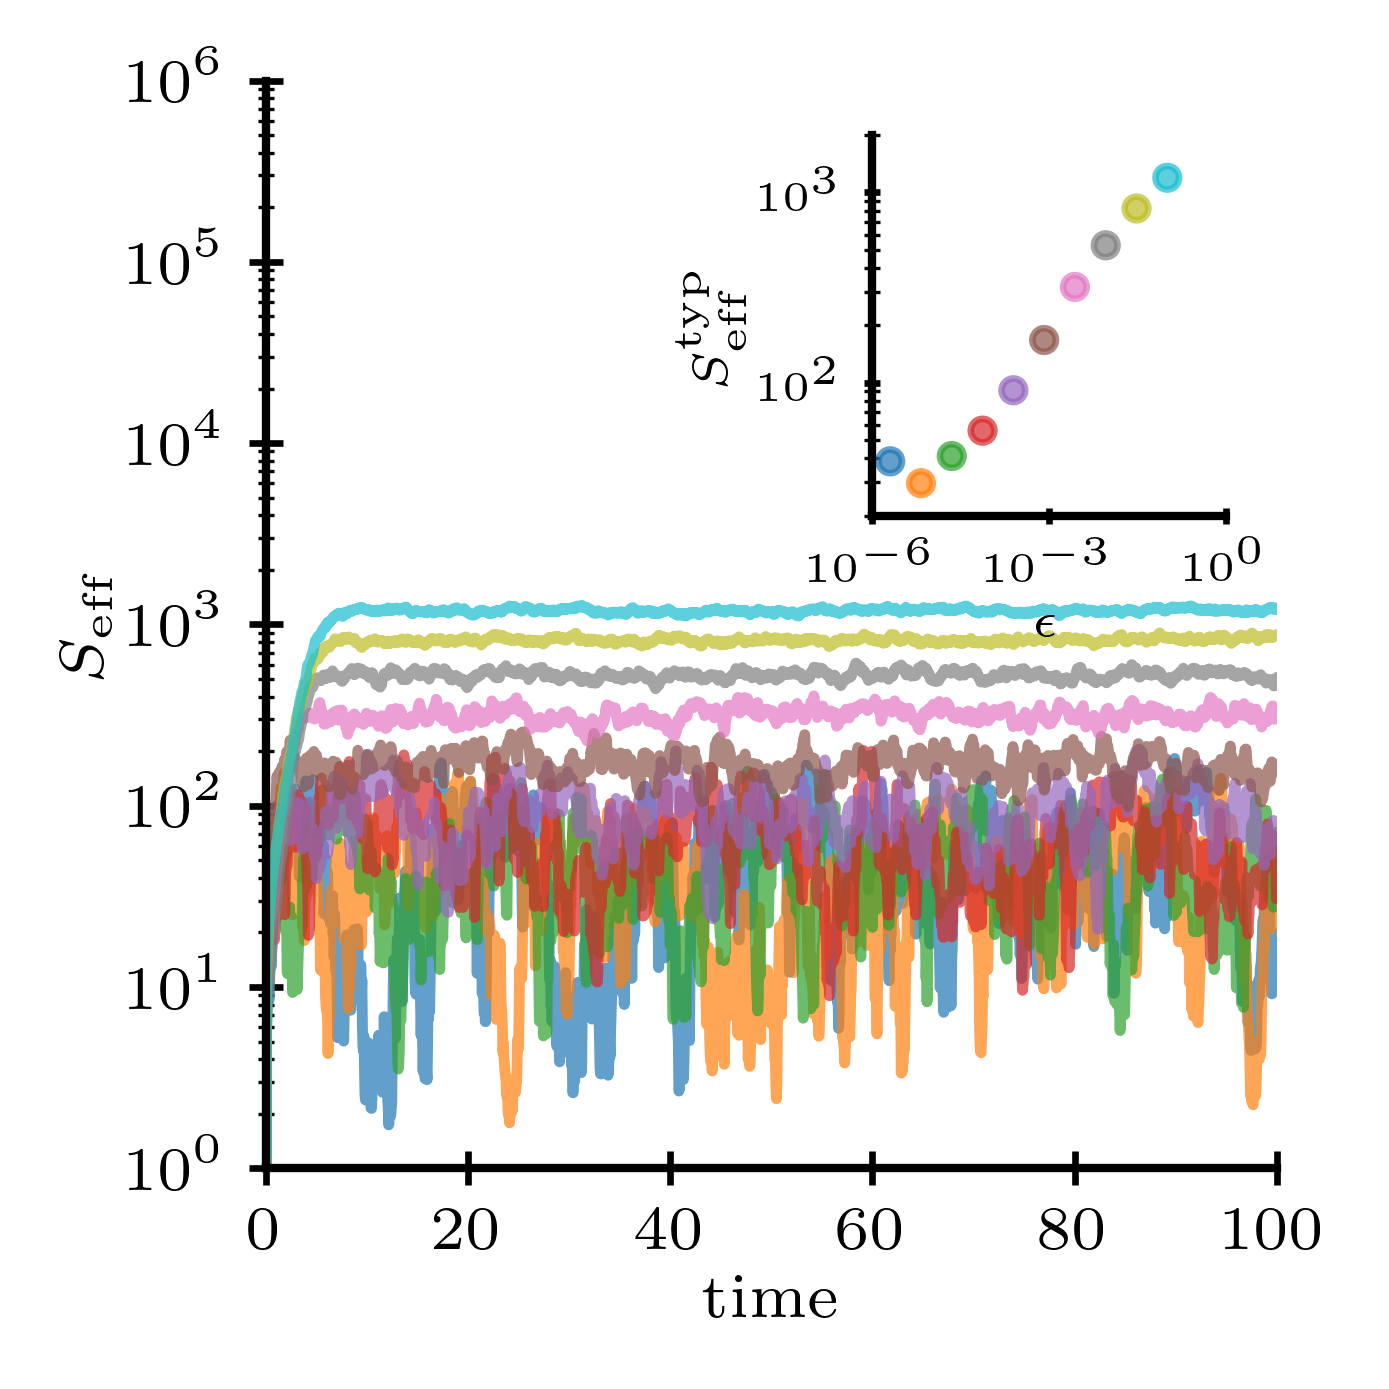

In [5]:
fig, ax = plt.subplots(figsize=(2.2, 2.2), layout='constrained')

alpha = 1.2
typical_diversities = []
colors = []
for epsilon in epsilons:
    t =  results_for_epsilon[epsilon]['t']
    
    Seff =  results_for_epsilon[epsilon]['Seff']
    line, = ax.plot(t, Seff, alpha=0.7)
    colors.append(line.get_color())    
    
    typical_Seff = lib.geometric_mean_after_burn(Seff)
    typical_diversities.append(typical_Seff)

ax.set_yscale('log')
ax.set_xlim(0, 100)
ax.set_ylim(1, 1e6)
ax.set_xlabel(r'time')
ax.set_ylabel(r'$S_{\mathrm{eff}}$');

inset = ax.inset_axes([0.6, 0.6, 0.35, 0.35])
inset.scatter(epsilons, typical_diversities, s=8, c=np.asarray(colors), alpha=0.7)
inset.set_xscale('log')
inset.set_yscale('log')

inset.set_xlabel(r'$\epsilon$', fontsize=6)
inset.set_ylabel(r'$S_{\mathrm{eff}}^{\mathrm{typ}}$', fontsize=6)
inset.tick_params(axis='both', labelsize=5, length=2)
inset.set_xlim([0.05 / T_star, 1e0])
inset.set_ylim([2e1, 2e3])
plt.savefig('../../figures/how_to_maintain_diversity/scaling_of_diversity_with_saturation.pdf', bbox_inches='tight', dpi=200, transparent=True);

/var/folders/cw/c094k5y90lg8zmsxks2359c80000gn/T/ipykernel_62181/3890585840.py:9: RuntimeWarning: divide by zero encountered in log
  ax[2].plot(results_for_epsilon[epsilon]['t'], np.log(results_for_epsilon[epsilon]['Seff'])/np.log(results_for_epsilon[epsilon]['S']), alpha=0.7)
/var/folders/cw/c094k5y90lg8zmsxks2359c80000gn/T/ipykernel_62181/3890585840.py:9: RuntimeWarning: invalid value encountered in divide
  ax[2].plot(results_for_epsilon[epsilon]['t'], np.log(results_for_epsilon[epsilon]['Seff'])/np.log(results_for_epsilon[epsilon]['S']), alpha=0.7)


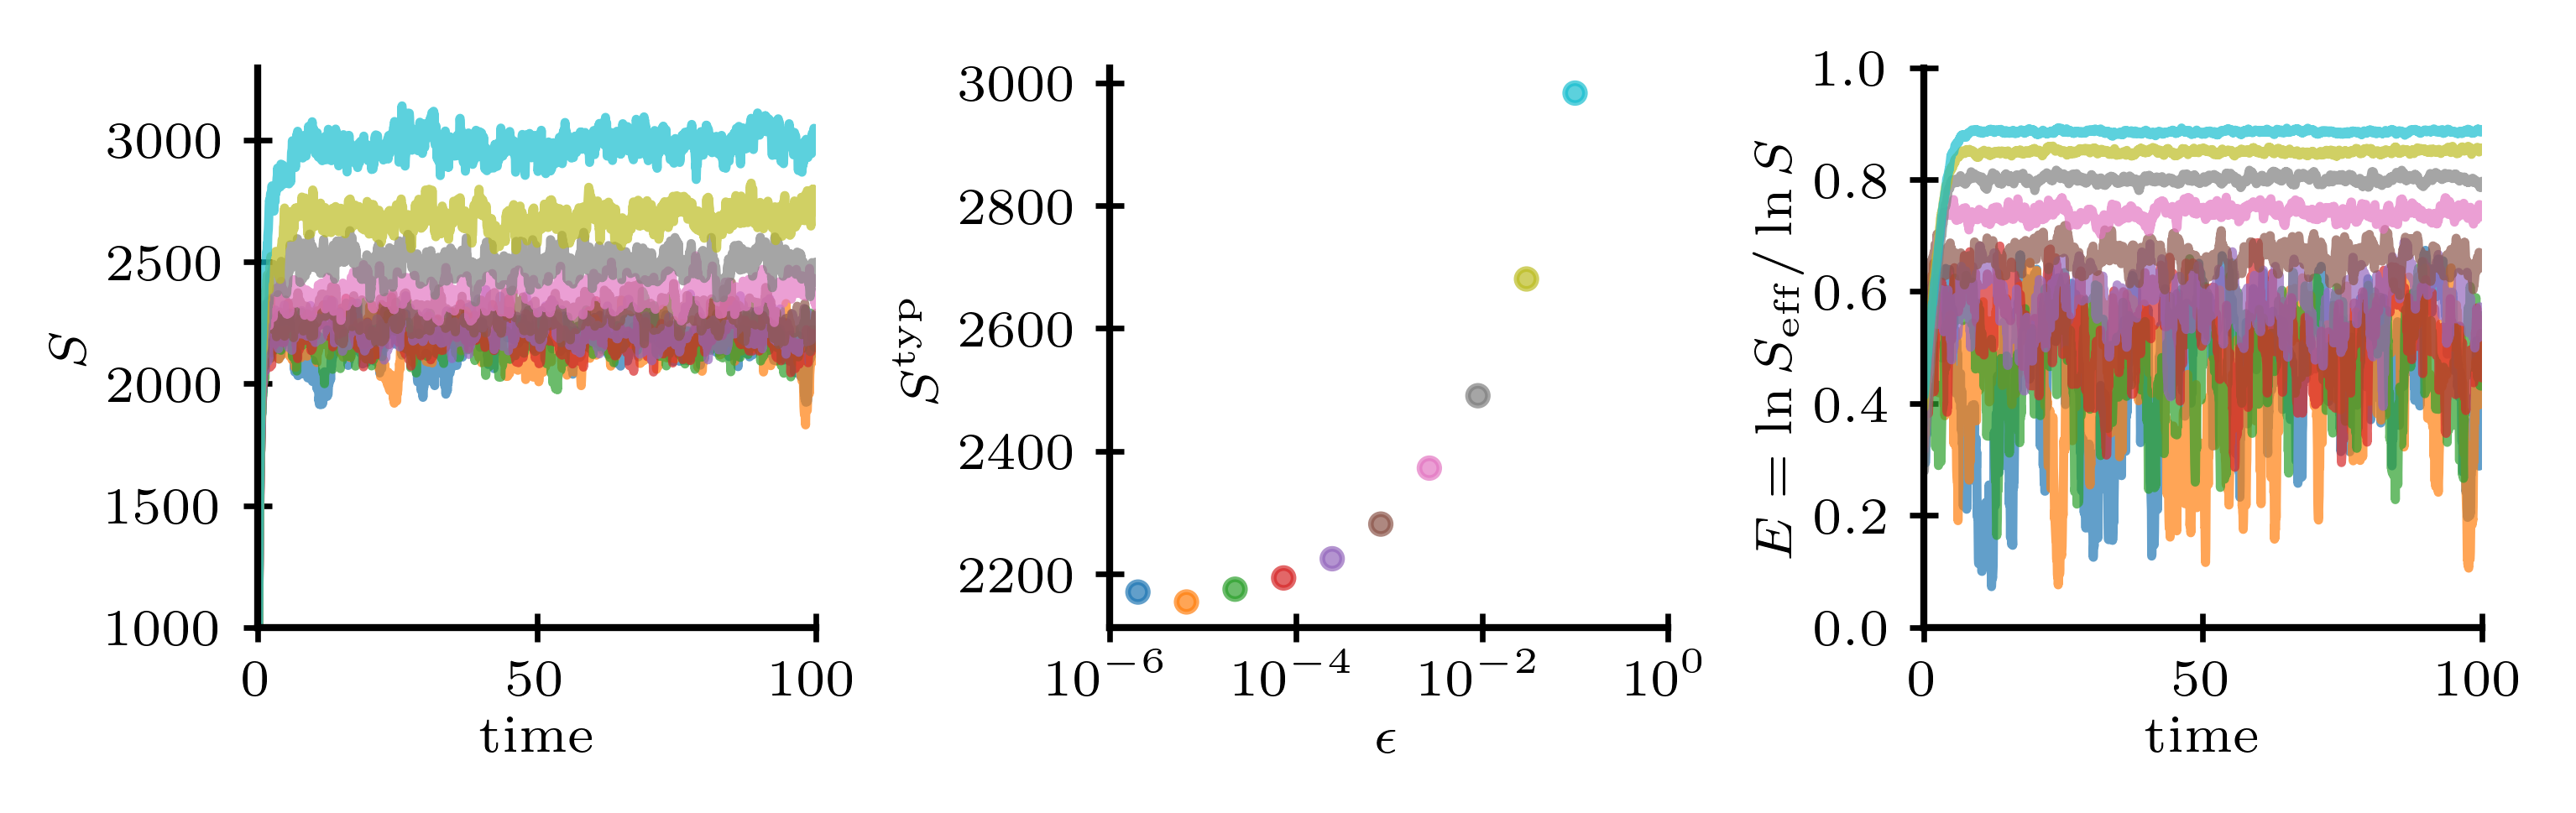

In [158]:
fig, ax = plt.subplots(1, 3, figsize=(5, 1.5), layout='constrained')
D = 1
gamma = 0.2
alpha = 1.2
typical_richness = []
T_stars = []
for epsilon in epsilons:   
    ax[0].plot(results_for_epsilon[epsilon]['t'], results_for_epsilon[epsilon]['S'], alpha=0.7)
    ax[2].plot(results_for_epsilon[epsilon]['t'], np.log(results_for_epsilon[epsilon]['Seff'])/np.log(results_for_epsilon[epsilon]['S']), alpha=0.7)
    
    S =  results_for_epsilon[epsilon]['S']
    typical_richness.append(lib.geometric_mean_after_burn(S))
        
ax[0].set_xlim(0, 100)
ax[0].set_xlabel(r'time')
ax[0].set_ylabel(r'$S$')
ax[0].set_ylim(1e3, None)

ax[1].set_xlabel(r'$\epsilon$')
ax[1].set_ylabel(r'$S^{\mathrm{typ}}$')
ax[1].scatter(epsilons, typical_richness, s=8, c=np.asarray(colors), alpha=0.7)
ax[1].set_xscale('log')
ax[1].set_xlim([0.05 / T_star, 1e0])

ax[2].set_xlabel(r'time')
ax[2].set_ylabel(r'$E = \ln S_{\mathrm{eff}}/ \ln S$')
ax[2].set_xlim(0, 100)
ax[2].set_ylim(0, 1);